In [108]:
###### import numpy as np
import scipy
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.integrate import odeint
import numpy as np

In [109]:
phi = var(r'φ') # scalar field
lam = var(r'λ') 
k = 1
lam =4
show(lam)
V0 = var(r'V_0')

# Expression for V
def V(V0,phi):
    return V0*exp(-lam*k*phi)

V = function('V')(phi)
V = V0*exp(-lam*k*phi)
dVdφ  = V.diff(phi)

# V prime:
N = var('N')
Phi = function(r'Φ')(N)
dvdΦ = dVdφ.subs(phi == Phi)
show(dvdΦ)

4

-4*V_0*e^(-4*Φ(N))

In [110]:

ohm_m = 0.3
Ho = 6.1324e-61 # Hubble constant in reduced plank mass units
rho_c0 = (3*Ho^2/(k^2)) # current critical energy density
V_value = rho_c0*1e12 #

#V_value = rho_c0
gam = 1
Ni = 0
show(V_value)

1.12818989280000e-108

In [111]:
def solveCopelandKG(X,N):
    a = exp(N) # N = ln(a)
    ai = exp(Ni)
    rho_m = rho_c0*ohm_m*(a*ai)^(-3)
    Vfunc = V.subs(V0 == V_value,phi ==X[0])
    dVfunc = dvdΦ.subs(V0 == V_value,Phi ==X[0])
    H2 = (rho_m + Vfunc)/(3-.5*(X[1])^2)
    HdotH2 = -0.5*((X[1])^2+ gam*rho_m/H2)
    x1prime = X[1]
    x2prime = -(3+HdotH2)*X[1] - dVfunc/H2
    return [x1prime,x2prime,Vfunc]

In [114]:
dPhi = Phi.diff(N)
X = [Phi,dPhi]
show(solveCopelandKG([1,0,V_value],Ni))

[0,
 (4.51275957120000e-108)*e^(-4)/((3.76063297600000e-109)*e^(-4) + 1.20563726125400e-108),
 (1.12818989280000e-108)*e^(-4)]

1.12818989280000e-108

array([0.        , 0.00747618, 0.01648103, 0.02762633, 0.04165905,
       0.05946964, 0.08207851, 0.11058499, 0.14606155, 0.18938207,
       0.24099177, 0.30066012, 0.36729263, 0.4388923 , 0.51272733,
       0.58568463, 0.65470882, 0.71719574, 0.77124441, 0.81574069,
       0.85030446, 0.87515769, 0.89096574, 0.89868647, 0.89944384,
       0.89442983, 0.88483264, 0.87178636, 0.85633768, 0.8394255 ,
       0.82187034, 0.80437087, 0.78750573, 0.77173869, 0.75742623,
       0.74482612, 0.73410671, 0.72535612, 0.71859139, 0.7137674 ,
       0.71078567, 0.70950314, 0.70974102, 0.71129378, 0.71393812,
       0.71744194, 0.72157282, 0.72610599, 0.73083129, 0.73555901,
       0.7401243 , 0.74439015, 0.74824885, 0.75162212, 0.75446001,
       0.75673877, 0.75845802, 0.75963738, 0.7603128 , 0.76053285,
       0.7603551 , 0.7598427 , 0.75906134, 0.75807654, 0.75695142,
       0.75574484, 0.75451003, 0.75329351, 0.75213458, 0.75106497,
       0.75010887, 0.74928314, 0.74859786, 0.74805691, 0.74765861,
       0.74739669, 0.74726107, 0.74723874, 0.7473146 , 0.74747232,
       0.74769503, 0.74796594, 0.74826895, 0.74858912, 0.74891299,
       0.74922885, 0.74952693, 0.74979942, 0.75004049, 0.75024629,
       0.75041464, 0.75054495, 0.75063813, 0.75069615, 0.75072196,
       0.75071922, 0.75069202, 0.75064476, 0.7505819 , 0.75050778])

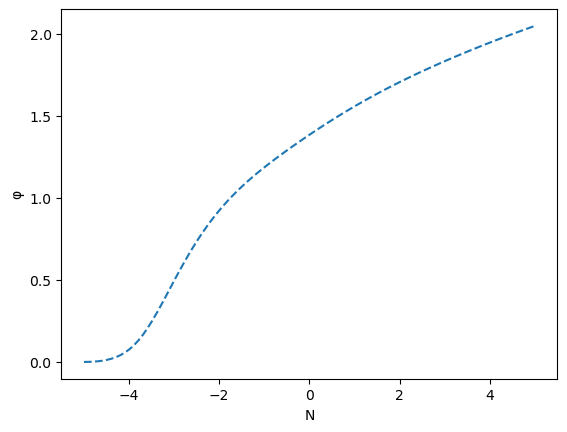

In [115]:
Nrange = np.linspace(-5,5,100)
Ni = Nrange[0]
sol = odeint(solveCopelandKG,[1,0,V_value],t=Nrange)
show(V_value)
# Plot of φ against redshift
phi_sol = sol[:,0]
phi_prime = sol[:,1]
Vnumber = sol[:,2]
show(phi_prime)
#Pot = V.subs(V0 == V_value,phi==phi_prime)
#show(Vnumber)

z_values = exp(-Nrange)
plt.xlabel("N")
plt.ylabel(r"φ")
plt.plot(Nrange,log(phi_sol),'--')

In [116]:
# Multiple Values of Q
def other_parameters(fi,dfi,V,N):
    a = exp(N) # N = ln(a)
    ai = exp(Ni)
    z = exp(-N)-1
    rho_m = rho_c0*ohm_m*(a*ai)^(-3) #1e7 is that initial pmi value
    #show(rho_m)
    #rho_m = rho_c0*ohm_m*a^(-3)
    #show(V.size)
    H2 = (rho_m + V)/(3-1/2*dfi^2)
    rho_φ = 0.5*(dfi^2*H2) + V #Energy density of φ (ρ_φ)
    #ratio_rho = rho_φ/rho_m
    
    O_φ = ((k^2)/3)*(rho_φ/H2) # Ωφ
    O_m = 1-O_φ
    #ratio_O = O_φ/O_m
    
    Pφ = 0.5*(dfi^2*H2) - V
    Y_φ = (Pφ+rho_φ)/rho_φ
    w = Pφ/rho_φ #Equation of State wΦ
    return z,rho_φ,Pφ,O_φ,O_m,w,Y_φ,rho_m

In [117]:
z,rho_s,P,O_Q,O_m,w,Y_Q,rho_m = other_parameters(phi_sol,phi_prime,Vnumber,Nrange)
Z = z+1
#show(Y_Q)

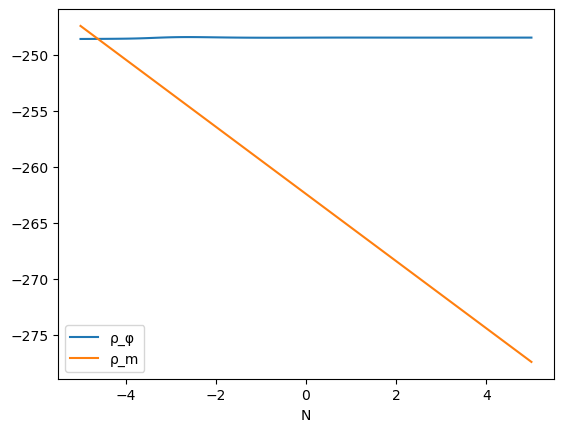

In [119]:
# Plots of φ,φ',ωφ,ρφ,Ωφ vs N

#plt.plot(Nrange,phi_sol, label  =r"φ")
#plt.plot(Nrange,phi_prime, label  =r"φ'")
plt.plot(Nrange,log(rho_s),label=r"ρ_φ")
plt.plot(Nrange,log(rho_m),label=r"ρ_m")
#plt.plot(Nrange,P,label=r"P_φ") 
#plt.plot(Nrange,O_Q,label=r"Ω_φ") 
#plt.plot(Nrange,w,label=r"ω") 
plt.xlabel("N")
plt.legend()

### Oberservations: change
Parameters experience a change of shape at N = 0. This is current day. \
$P_φ$ is zero for all N. This makes sense as $P_φ = (γ-1)ρ_φ$ and we have set $γ$ to 1. \
$ρ_φ$ is steadily increases from zero at a constant rate for N less than zero before it has a small rapid expansion at N = 0 before it plateaus. \


0.9999999999973792

0.26930289132419055

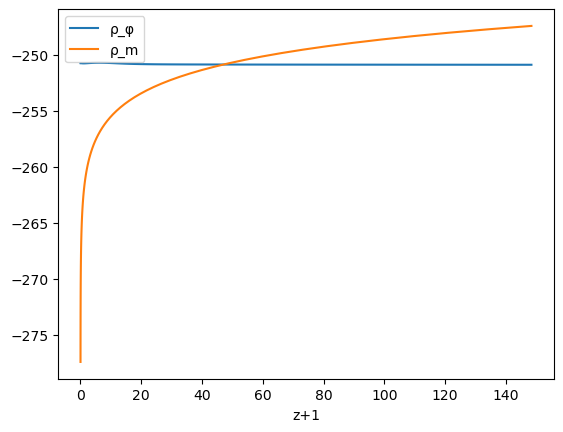

In [65]:
# Plots of φ,φ',ωφ,ρφ,Ωφ vs z+1
#plt.plot(Z,phi_sol, label  =r"φ")
#plt.plot(Z,phi_prime, label  =r"φ'")
plt.plot(Z,log(rho_s),label=r"ρ_φ")
plt.plot(Z,log(rho_m),label=r"ρ_m")
#show(Y_Q)
#plt.plot(Z,(Y_Q),label=r"γ_φ")
#plt.plot(Z,ratio_O,label = r"ratio_Ω")
#plt.plot(Z,P,label=r"P_φ")
show(max(O_Q))
show(max(Y_Q))
#plt.plot(Z,log(O_Q),label=r"Ω_φ") 
#plt.plot(Z,log(O_m),label=r"Ω_m")
#plt.plot(Z,O_m/O_Q,label=r"ratio_Ω")
#plt.plot(Z,w,label=r"ω") 
plt.xlabel("z+1")
#plt.xscale('log')
plt.legend()

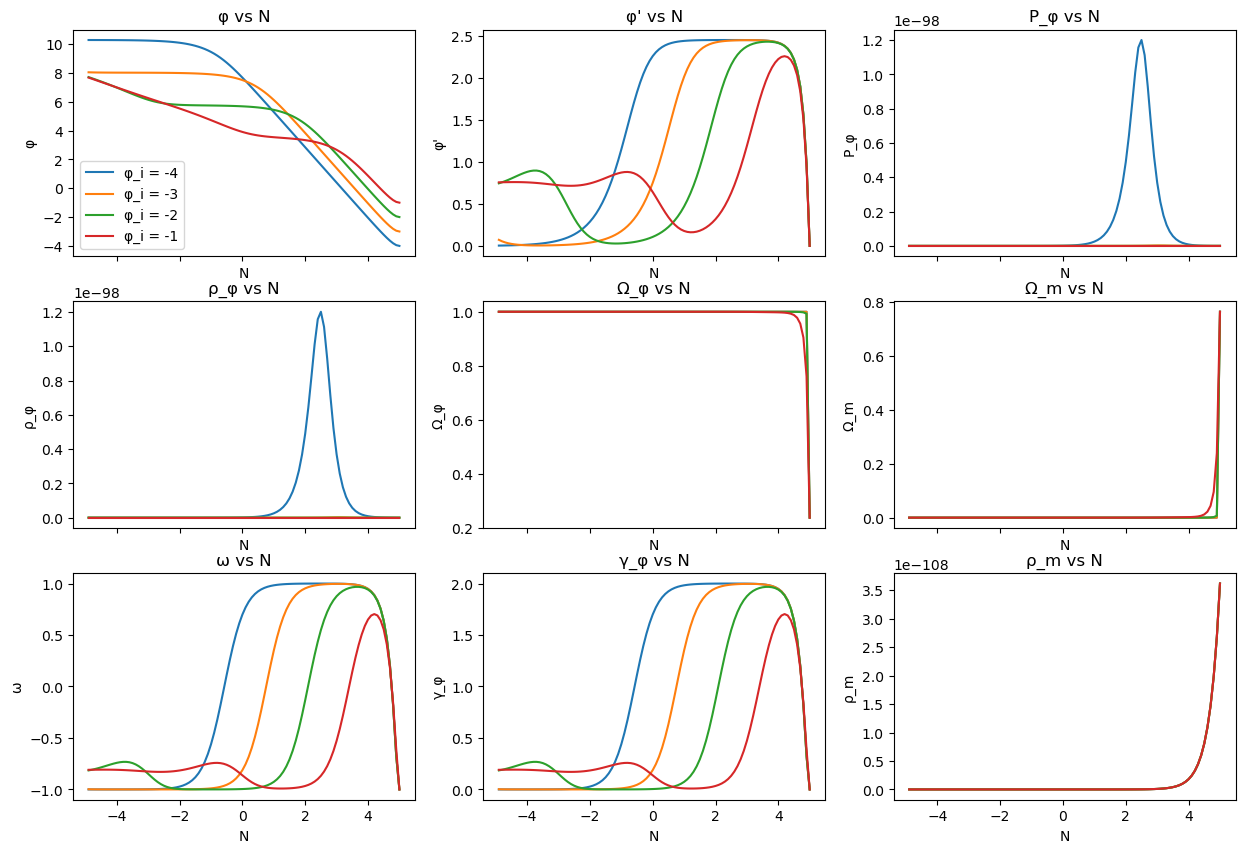

In [47]:
# Test for Attacting Q values
Nrange = np.arange(-5,5,.1)
z_list = []
rho_list = []
P_list = []
om_list = []
w_list = []
Q_list = []
fig, axs = plt.subplots(3,3, figsize=(15, 10),sharex=True)

for i in range(-4,0,1):
    solQ = odeint(solveCopelandKG,[i,0,V_value],t=Nrange)
    '''When I generate solutions, I also find the corresponding z,ωφ,ρφ,Ωφ,Pφ values for all initial Q values ranged. '''
    z,rho,P,O_Q,O_m,w,Y_Q,rho_m = other_parameters(solQ[:,0],solQ[:,1],solQ[:,2],Nrange)
    z_list.append(z);rho_list.append(rho);P_list.append(P);om_list.append(O_Q);w_list.append(w)

    # Use Subplots to observe each parameter over all N for a different intial value of φ
    axs[0,0].plot(-Nrange,solQ[:,0],label=r"φ_i = {}".format(i))
    axs[0,0].set(ylabel = r"φ", xlabel = "N",title=r"φ vs N")
    axs[0,0].legend()

    axs[0,1].plot(-Nrange,solQ[:,1],label=r"φ_i = {}".format(i))
    axs[0,1].set(ylabel = r"φ'", xlabel = "N",title=r"φ' vs N")
    #axs[0,1].legend()

    axs[0,2].plot(-Nrange,P,label=r"φ_i = {}".format(i))
    axs[0,2].set(ylabel = r"P_φ", xlabel = "N",title=r"P_φ vs N")
    #axs[0,2].legend()

    axs[1,0].plot(-Nrange,rho,label=r"φ_i = {}".format(i))
    axs[1,0].set(ylabel = r"ρ_φ", xlabel = "N",title=r"ρ_φ vs N")
    #axs[1,0].legend()

    axs[1,1].plot(-Nrange,O_Q,label=r"φ_i = {}".format(i))
    axs[1,1].set(ylabel = r"Ω_φ", xlabel = "N",title=r"Ω_φ vs N")
    #axs[1,1].legend()

    axs[1,2].plot(-Nrange,O_m,label=r"φ_i = {}".format(i))
    axs[1,2].set(ylabel = r"Ω_m", xlabel = "N",title=r"Ω_m vs N")
    #axs[1,2].legend()

    axs[2,0].plot(-Nrange,w,label=r"φ_i = {}".format(i))
    axs[2,0].set(ylabel = r"ω", xlabel = "N",title=r"ω vs N")
    #axs[2,0].legend()

    axs[2,1].plot(-Nrange,Y_Q,label=r"φ_i = {}".format(i))
    axs[2,1].set(ylabel = r"γ_φ", xlabel = "N",title=r"γ_φ vs N")
    #axs[2,1].legend()

    axs[2,2].plot(-Nrange,rho_m,label=r"φ_i = {}".format(i))
    axs[2,2].set(ylabel = r"ρ_m", xlabel = "N",title=r"ρ_m vs N")
    #axs[2,1].legend()
    

#axs[0,0].set_xscale('log')
#axs[0,0].set_yscale('log')

#def multipleQ(Q,N):
#axs[0,0].ylabel()
    #axs[0,0].xlabel()    
    

### Improvement to code above:
The code below is the same as the code above, but now allows you to easily choose what is plotted on the x-axis. Also changed the range of N values to include Negative values as well. 

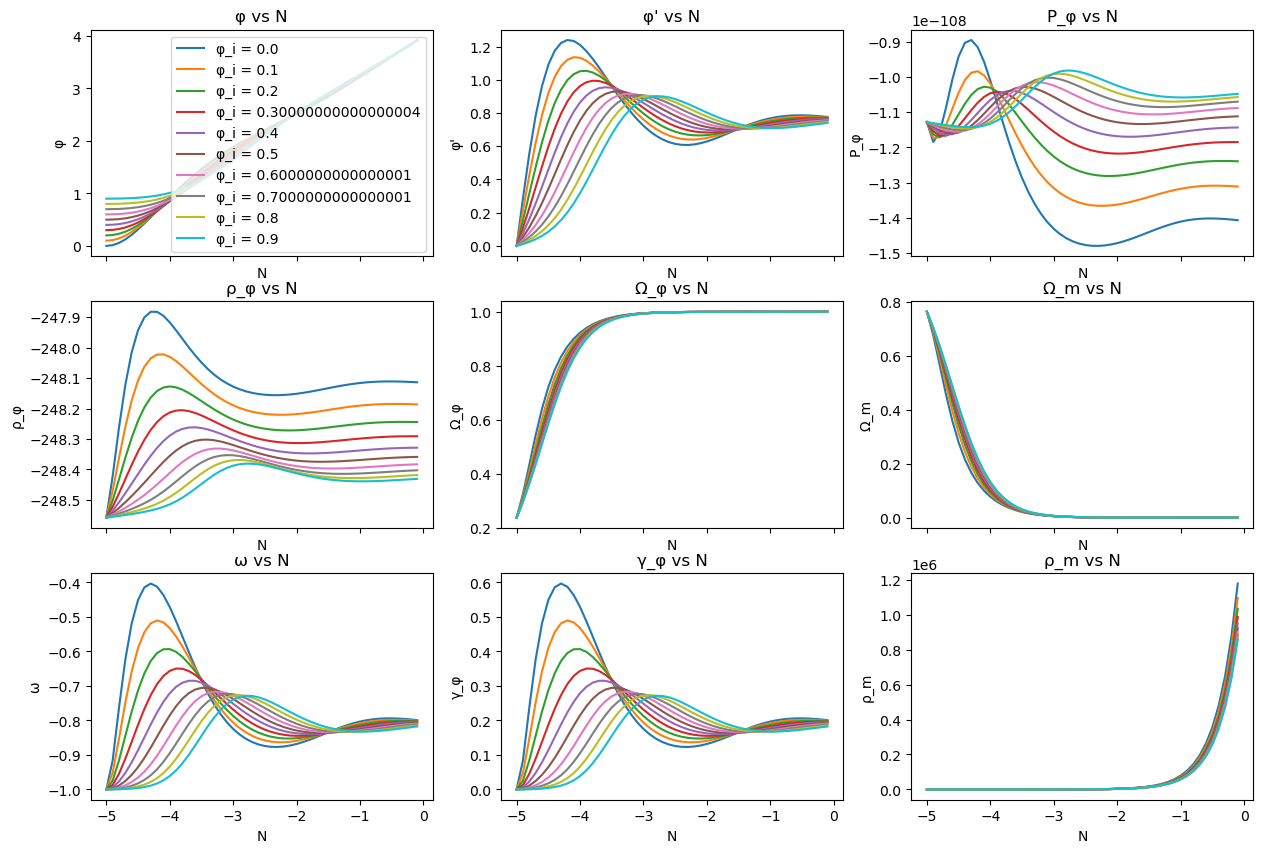

In [50]:
Nrange = np.arange(-5,0,.1)
fig, axs = plt.subplots(3,3, figsize=(15, 10),sharex=True)
def xaxis(x,label,i):
    #axs[0,0].set_xscale('log')
        
    #axs[0,0].set_yscale('log')
    axs[0,0].plot(x,solQ[:,0],label=r"φ_i = {}".format(i))
    axs[0,0].set(ylabel = r"φ", xlabel = "{}".format(label),title=r"φ vs {}".format(label))
    if label == "z+1":
        axs[0,0].xaxis.set_inverted(True)
    axs[0,0].legend()
    
    axs[0,1].plot(x,solQ[:,1],label=r"φ_i = {}".format(i))
    axs[0,1].set(ylabel = r"φ'", xlabel = "{}".format(label),title=r"φ' vs {}".format(label))
    #axs[0,1].legend()
    
    axs[0,2].plot(x,P,label=r"φ_i = {}".format(i))
    axs[0,2].set(ylabel = r"P_φ", xlabel = "{}".format(label),title=r"P_φ vs {}".format(label))
    #axs[0,2].legend()
    
    axs[1,0].plot(x,log(rho),label=r"φ_i = {}".format(i))
    axs[1,0].set(ylabel = r"ρ_φ", xlabel = "{}".format(label),title=r"ρ_φ vs {}".format(label))
    #axs[1,0].legend()
    
    axs[1,1].plot(x,O_Q,label=r"φ_i = {}".format(i))
    axs[1,1].set(ylabel = r"Ω_φ", xlabel = "{}".format(label),title=r"Ω_φ vs {}".format(label))
    #axs[1,1].legend()
    
    axs[1,2].plot(x,O_m,label=r"φ_i = {}".format(i))
    axs[1,2].set(ylabel = r"Ω_m", xlabel = "{}".format(label),title=r"Ω_m vs {}".format(label))
    #axs[1,2].legend()

    axs[2,0].plot(x,w,label=r"φ_i = {}".format(i))
    axs[2,0].set(ylabel = r"ω", xlabel = "{}".format(label),title=r"ω vs {}".format(label))
    #axs[2,0].legend()

    axs[2,1].plot(x,Y_Q,label=r"φ_i = {}".format(i))
    axs[2,1].set(ylabel = r"γ_φ", xlabel = "{}".format(label),title=r"γ_φ vs {}".format(label))
    #axs[2,1].legend()

    axs[2,2].plot(x,rho/rho_m,label=r"φ_i = {}".format(i))
    axs[2,2].set(ylabel = r"ρ_m", xlabel = "{}".format(label),title=r"ρ_m vs {}".format(label))
    
Q_values = np.arange(0,1,.1)
for i in Q_values:
    Ni = Nrange[0]
    solQ = odeint(solveCopelandKG,[i,0,V_value],t=Nrange)
    '''When I generate solutions, I also find the corresponding z,ωφ,ρφ,Ωφ,Pφ values for all initial Q values ranged. '''
    z,rho,P,O_Q,O_m,w,Y_Q,rho_m = other_parameters(solQ[:,0],solQ[:,1],solQ[:,2],Nrange)
    Z = z+1
    xaxis(Nrange,"N",i) # Here is where you can alter whether to view graphs w.r.t to N or z+1
